1) Importing Required modules:


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
from sklearn.metrics import mean_absolute_percentage_error

print('Libraries loaded.')

Libraries loaded.


2) Loading the Data: 

In [2]:
# --- Demand data ---
df_demand = pd.read_excel('C:/Users/Rajesh/Desktop/.ai recruitment/PGCB_date_power_demand.xlsx')
df_demand['datetime'] = pd.to_datetime(df_demand['datetime'])

# --- Weather data ---
df_weather = pd.read_excel("C:/Users/Rajesh/Desktop/.ai recruitment/weather_data.xlsx", skiprows=2, header=0)
df_weather.columns = [
    'datetime', 'temperature_2m', 'relative_humidity_2m',
    'apparent_temperature', 'precipitation', 'dew_point_2m',
    'soil_temperature', 'wind_direction_10m', 'cloud_cover', 'sunshine_duration'
]
df_weather['datetime'] = pd.to_datetime(df_weather['datetime'], errors='coerce')
df_weather = df_weather.dropna(subset=['datetime'])  

for col in df_weather.columns[1:]:
    df_weather[col] = pd.to_numeric(df_weather[col], errors='coerce')

# --- Economic data ---
df_econ_raw = pd.read_csv("C:/Users/Rajesh/Desktop/.ai recruitment/economic_full_1.csv")

print('Demand shape :', df_demand.shape)
print('Weather shape:', df_weather.shape)
print('Econ shape   :', df_econ_raw.shape)
print('\nDemand date range:', df_demand['datetime'].min(), '->', df_demand['datetime'].max())
print('Weather date range:', df_weather['datetime'].min(), '->', df_weather['datetime'].max())

Demand shape : (92650, 15)
Weather shape: (107304, 10)
Econ shape   : (1516, 69)

Demand date range: 2015-04-19 00:00:00 -> 2025-06-17 12:00:00
Weather date range: 2014-01-01 00:00:00 -> 2026-03-29 23:00:00


3) Data preparation:

Hourly (:00) rows: 88469
Half-hourly (:30) rows: 4181

Rows after removing :30 timestamps: 88469
Duplicate timestamps removed: 423
Missing hours after reindexing: 1055

Missing values per column:
generation_mw            1055
demand_mw                1055
load_shedding            1055
gas                      1055
liquid_fuel              1055
coal                     1055
hydro                    1055
solar                   21572
wind                    71192
india_bheramara_hvdc     1055
india_tripura            1055
india_adani             82062
nepal                   83968
remarks                 83348
dtype: int64
Missing values after same-week fill: 391
Some NaNs remain — applying fallback: same hour 2 weeks ago
Missing after 2-week fill: 41
Applying final fallback: forward fill for very early rows

Final missing count: 0
Anomalies detected: 61
Sample anomalous values:
datetime
2015-08-09 13:00:00     4071.0
2016-02-18 23:00:00     1419.0
2016-09-16 06:00:00      746.0
2016-09-

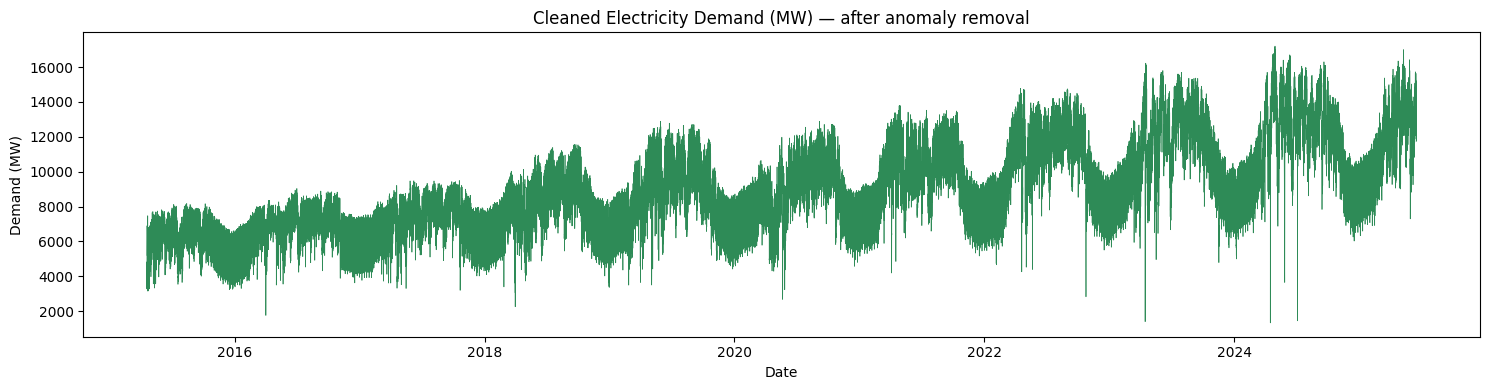

Shape after weather merge: (89101, 21)
Missing after weather fill: 0
Shape after economic merge: (89101, 27)
Economic columns added: ['gdp_growth', 'gdp_per_capita', 'electricity_access_pct', 'urban_pop_pct', 'industry_pct_gdp']


In [3]:
# Fixing the half-hourly timestamps by weighted average
df_demand = df_demand.sort_values('datetime').reset_index(drop=True)

mask_30 = df_demand['datetime'].dt.minute == 30
df_half  = df_demand[mask_30].copy()   # the :30 readings
df_hour  = df_demand[~mask_30].copy()  # the :00 readings

print(f'Hourly (:00) rows: {len(df_hour)}')
print(f'Half-hourly (:30) rows: {len(df_half)}')

NUMERIC_COLS = ['demand_mw', 'generation_mw', 'load_shedding',
                'gas', 'liquid_fuel', 'coal', 'hydro']

df_half_indexed = df_half.copy()
df_half_indexed['hour_key'] = df_half_indexed['datetime'].dt.floor('H')

df_hour_indexed = df_hour.set_index('datetime')

for _, row in df_half_indexed.iterrows():
    key = row['hour_key']
    if key in df_hour_indexed.index:
        for col in NUMERIC_COLS:
            original = df_hour_indexed.at[key, col]
            blended  = 0.6 * original + 0.4 * row[col]
            df_hour_indexed.at[key, col] = blended

df_demand_clean = df_hour_indexed.reset_index()
print(f'\nRows after removing :30 timestamps: {len(df_demand_clean)}')




df_demand_clean = df_demand_clean.sort_values('datetime')
df_demand_clean = df_demand_clean.set_index('datetime')

n_dupes = df_demand_clean.index.duplicated().sum()
print(f'Duplicate timestamps removed: {n_dupes}')
df_demand_clean = df_demand_clean[~df_demand_clean.index.duplicated(keep='first')]

#Making a perfect Hourly grid
df_demand_clean = df_demand_clean.asfreq('H')
n_missing = df_demand_clean['demand_mw'].isna().sum()
print(f'Missing hours after reindexing: {n_missing}')

print('\nMissing values per column:')
print(df_demand_clean.isnull().sum())

#Fixing Missing Values

# ── SAME HOUR LAST WEEK FILL ──


one_week_ago = df_demand_clean['demand_mw'].shift(168)

# Step B: Fill NaN values in demand_mw with the same-week value
# .fillna(other) replaces NaN only — non-NaN values are left unchanged
df_demand_clean['demand_mw'] = df_demand_clean['demand_mw'].fillna(one_week_ago)

#Some Values might still be missing as the value last week can also be NAN.
still_missing = df_demand_clean['demand_mw'].isna().sum()
print(f'Missing values after same-week fill: {still_missing}')                                                                                                                                                                                                        
# This can happen if the same hour 1 week ago was ALSO missing
# (e.g. during a long outage that spans multiple weeks)
# We fall back to 2 weeks ago hence for values already shifted , we are shifting three weeks and the longest gap is 517hr ,Thus almost no NAN values are remaining except very first rows where the data for previous week is not available,for such cases and remaining small intervals we will use forward fill.

if df_demand_clean['demand_mw'].isna().sum() > 0:
    print('Some NaNs remain — applying fallback: same hour 2 weeks ago')

    two_weeks_ago = df_demand_clean['demand_mw'].shift(336)  
    df_demand_clean['demand_mw'] = df_demand_clean['demand_mw'].fillna(two_weeks_ago)

    still_missing = df_demand_clean['demand_mw'].isna().sum()
    print(f'Missing after 2-week fill: {still_missing}')

#forward fill
if df_demand_clean['demand_mw'].isna().sum() > 0:
    print('Applying final fallback: forward fill for very early rows')
    df_demand_clean['demand_mw'] = (
        df_demand_clean['demand_mw']
        .fillna(method='ffill')
        .fillna(method='bfill')
    )

print(f'\nFinal missing count: {df_demand_clean["demand_mw"].isna().sum()}')

#Fixing Anomalies 
WINDOW    = 168   
THRESHOLD = 3.5  

series = df_demand_clean['demand_mw'].copy()

roll_mean   = series.rolling(window=WINDOW, center=True, min_periods=24).mean()
roll_std    = series.rolling(window=WINDOW, center=True, min_periods=24).std()
roll_median = series.rolling(window=WINDOW, center=True, min_periods=24).median()

z_scores  = (series - roll_mean) / (roll_std + 1e-8)
is_anomaly = z_scores.abs() > THRESHOLD

print(f'Anomalies detected: {is_anomaly.sum()}')
print('Sample anomalous values:')
print(series[is_anomaly].head(10))

#replacing anomalies with the local rolling median
series[is_anomaly] = roll_median[is_anomaly]
df_demand_clean['demand_mw'] = series

# Plot of cleaned series
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(df_demand_clean.index, df_demand_clean['demand_mw'],
        lw=0.5, color='seagreen', label='Cleaned demand')
ax.set_title('Cleaned Electricity Demand (MW) — after anomaly removal')
ax.set_xlabel('Date')
ax.set_ylabel('Demand (MW)')
plt.tight_layout()
plt.savefig('cleaned_demand.png', dpi=150)
plt.show()

#merging Weather data 
df_weather = df_weather.sort_values('datetime').reset_index(drop=True)
weather_use_cols = ['datetime', 'temperature_2m', 'relative_humidity_2m',
                    'apparent_temperature', 'precipitation',
                    'cloud_cover', 'sunshine_duration']

df = df_demand_clean.merge(df_weather[weather_use_cols], on='datetime', how='left')

    # Forward-fill any missing weather (sensor dropouts)
for col in weather_use_cols[1:]:
    df[col] = df[col].fillna(method='ffill').fillna(method='bfill')

print('Shape after weather merge:', df.shape)
print('Missing after weather fill:', df[weather_use_cols[1:]].isna().sum().sum())

#Integrating economic data

# relevant indicators (chosen for coverage and economic relevance)
CHOSEN_INDICATORS = [
    'GDP growth (annual %)',
    'GDP per capita (current US$)',
    'Access to electricity (% of population)',
    'Urban population (% of total population)',
    'Industry (including construction), value added (% of GDP)',
]

year_cols = [str(y) for y in range(2015, 2024)]  # covers our data range

econ_rows = df_econ_raw[df_econ_raw['Indicator Name'].isin(CHOSEN_INDICATORS)]

econ_long = econ_rows[['Indicator Name'] + year_cols].melt(
    id_vars='Indicator Name', var_name='year', value_name='value')
econ_long['year'] = econ_long['year'].astype(int)

econ_pivot = econ_long.pivot(index='year', columns='Indicator Name', values='value').reset_index()

econ_pivot.columns.name = None
econ_pivot = econ_pivot.rename(columns={
    'GDP growth (annual %)': 'gdp_growth',
    'GDP per capita (current US$)': 'gdp_per_capita',
    'Access to electricity (% of population)': 'electricity_access_pct',
    'Urban population (% of total population)': 'urban_pop_pct',
    'Industry (including construction), value added (% of GDP)': 'industry_pct_gdp',
})

# Forward-fill any missing years in the economic data
econ_pivot = econ_pivot.sort_values('year')
for col in ['gdp_growth', 'gdp_per_capita', 'electricity_access_pct',
             'urban_pop_pct', 'industry_pct_gdp']:
    econ_pivot[col] = econ_pivot[col].interpolate(method='linear')

df['year'] = df['datetime'].dt.year
df = df.merge(econ_pivot, on='year', how='left')

print('Shape after economic merge:', df.shape)
print('Economic columns added:', ['gdp_growth','gdp_per_capita','electricity_access_pct',
                                    'urban_pop_pct','industry_pct_gdp'])

4) Feature Engineering:

In [4]:
df = df.sort_values('datetime').reset_index(drop=True)


# A. CALENDAR FEATURES:

df['hour']         = df['datetime'].dt.hour
df['day_of_week']  = df['datetime'].dt.dayofweek     
df['month']        = df['datetime'].dt.month
df['quarter']      = df['datetime'].dt.quarter
df['day_of_year']  = df['datetime'].dt.dayofyear
df['week_of_year'] = df['datetime'].dt.isocalendar().week.astype(int)
df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)

#  Cyclical encoding: 
df['hour_sin']   = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos']   = np.cos(2 * np.pi * df['hour'] / 24)
df['month_sin']  = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']  = np.cos(2 * np.pi * df['month'] / 12)
df['dow_sin']    = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']    = np.cos(2 * np.pi * df['day_of_week'] / 7)

print('Calendar features added.')

# B. LAG FEATURES — 

for lag in [1, 2, 3, 6, 12]:
    df[f'lag_{lag}h'] = df['demand_mw'].shift(lag)

df['lag_24h']  = df['demand_mw'].shift(24)    
df['lag_48h']  = df['demand_mw'].shift(48)    
df['lag_168h'] = df['demand_mw'].shift(168)   
df['lag_336h'] = df['demand_mw'].shift(336)   


for col in ['gas', 'coal', 'hydro', 'load_shedding']:
    df[f'{col}_lag1'] = df[col].shift(1)
    df[f'{col}_lag24'] = df[col].shift(24)

print('Lag features added.')


# C. ROLLING WINDOW FEATURES — 

demand_past = df['demand_mw'].shift(1)  # start from t-1

for w in [3, 6, 12, 24, 168]:
    df[f'roll_mean_{w}h'] = demand_past.rolling(w, min_periods=1).mean()
    df[f'roll_std_{w}h']  = demand_past.rolling(w, min_periods=1).std()


df['roll_range_24h'] = (
    demand_past.rolling(24, min_periods=1).max() -
    demand_past.rolling(24, min_periods=1).min()
)


df['demand_vs_daily_avg'] = df['demand_mw'].shift(1) - df['roll_mean_24h']

temp_past = df['temperature_2m'].shift(1)
df['temp_roll_mean_6h'] = temp_past.rolling(6, min_periods=1).mean()

print('Rolling features added.')


# D. DEFINING THE SUPERVISED LEARNING TARGET

df['target'] = df['demand_mw'].shift(-1)

df = df.dropna(subset=['target', 'lag_168h', 'lag_336h'])
df = df.reset_index(drop=True)

print(f'Final dataset: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Date range: {df["datetime"].min()} → {df["datetime"].max()}')

Calendar features added.
Lag features added.
Rolling features added.
Final dataset: 88764 rows × 71 columns
Date range: 2015-05-03 00:00:00 → 2025-06-17 11:00:00


5.Training and testing

In [5]:
# Columns to exclude from features 
EXCLUDE = ['datetime', 'demand_mw', 'target', 'year', 'remarks',
           'solar', 'wind', 'india_adani', 'nepal',   
           'india_bheramara_hvdc', 'india_tripura'   
           ]
FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE]

print(f'Number of features: {len(FEATURE_COLS)}')
print('Features:', FEATURE_COLS)

train_df = df[df['datetime'].dt.year <= 2023].copy()
test_df  = df[df['datetime'].dt.year == 2024].copy()

X_train = train_df[FEATURE_COLS]
y_train = train_df['target']
X_test  = test_df[FEATURE_COLS]
y_test  = test_df['target']

print(f'\nTrain: {len(X_train):,} rows  |  {train_df["datetime"].min().date()} → {train_df["datetime"].max().date()}')
print(f'Test : {len(X_test):,} rows  |  {test_df["datetime"].min().date()} → {test_df["datetime"].max().date()}')

Number of features: 60
Features: ['generation_mw', 'load_shedding', 'gas', 'liquid_fuel', 'coal', 'hydro', 'temperature_2m', 'relative_humidity_2m', 'apparent_temperature', 'precipitation', 'cloud_cover', 'sunshine_duration', 'electricity_access_pct', 'gdp_growth', 'gdp_per_capita', 'industry_pct_gdp', 'urban_pop_pct', 'hour', 'day_of_week', 'month', 'quarter', 'day_of_year', 'week_of_year', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'lag_1h', 'lag_2h', 'lag_3h', 'lag_6h', 'lag_12h', 'lag_24h', 'lag_48h', 'lag_168h', 'lag_336h', 'gas_lag1', 'gas_lag24', 'coal_lag1', 'coal_lag24', 'hydro_lag1', 'hydro_lag24', 'load_shedding_lag1', 'load_shedding_lag24', 'roll_mean_3h', 'roll_std_3h', 'roll_mean_6h', 'roll_std_6h', 'roll_mean_12h', 'roll_std_12h', 'roll_mean_24h', 'roll_std_24h', 'roll_mean_168h', 'roll_std_168h', 'roll_range_24h', 'demand_vs_daily_avg', 'temp_roll_mean_6h']

Train: 75,960 rows  |  2015-05-03 → 2023-12-31
Test : 8,784 rows  |  2

6.Model Training-Light GBM 

In [6]:
model = lgb.LGBMRegressor(
    n_estimators      = 2000,
    learning_rate     = 0.03,
    num_leaves        = 127,
    min_child_samples = 30,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 0.1,
    random_state      = 42,
    n_jobs            = -1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=False),
        lgb.log_evaluation(period=200)
    ]
)

print(f'\nBest iteration: {model.best_iteration_}')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020090 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10735
[LightGBM] [Info] Number of data points in the train set: 75960, number of used features: 60
[LightGBM] [Info] Start training from score 8310.229231
[200]	valid_0's l2: 171025
[400]	valid_0's l2: 169213

Best iteration: 304


7. Evaluation 

  Test MAPE : 2.46%
  Test MAE  : 264.8 MW
  Test RMSE : 407.4 MW
Result: Excellent — below 5% is industry-grade.


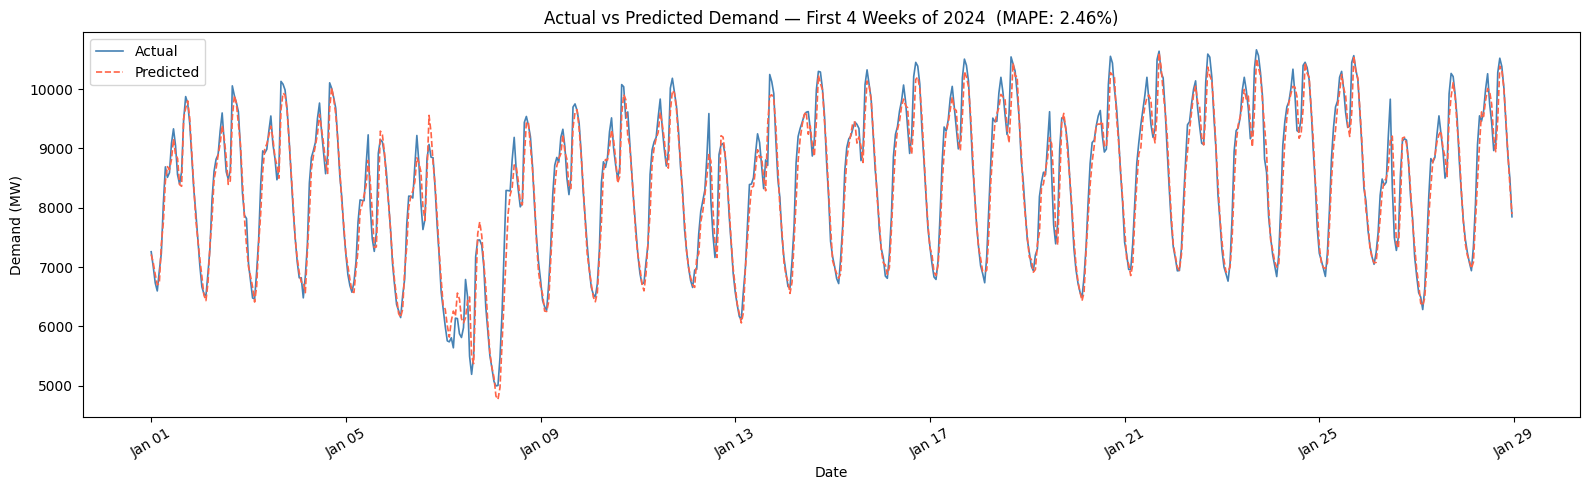

In [7]:
y_pred = model.predict(X_test)

mape = mean_absolute_percentage_error(y_test, y_pred) * 100
mae  = np.mean(np.abs(y_test.values - y_pred))
rmse = np.sqrt(np.mean((y_test.values - y_pred) ** 2))

print('=' * 45)
print(f'  Test MAPE : {mape:.2f}%')
print(f'  Test MAE  : {mae:.1f} MW')
print(f'  Test RMSE : {rmse:.1f} MW')
print('=' * 45)

if mape < 5:
    print('Result: Excellent — below 5% is industry-grade.')
elif mape < 10:
    print('Result: Good — below 10% is acceptable for short-term forecasting.')
else:
    print('Result: Needs improvement — check for data leakage or try more lag features.')

# Plot actual vs predicted — first 4 weeks of 2024
n_plot = 24 * 28  
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(test_df['datetime'].values[:n_plot], y_test.values[:n_plot],
        label='Actual', color='steelblue', lw=1.2)
ax.plot(test_df['datetime'].values[:n_plot], y_pred[:n_plot],
        label='Predicted', color='tomato', lw=1.2, ls='--')
ax.set_title(f'Actual vs Predicted Demand — First 4 Weeks of 2024  (MAPE: {mape:.2f}%)')
ax.set_xlabel('Date')
ax.set_ylabel('Demand (MW)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()

8.Feature Importance

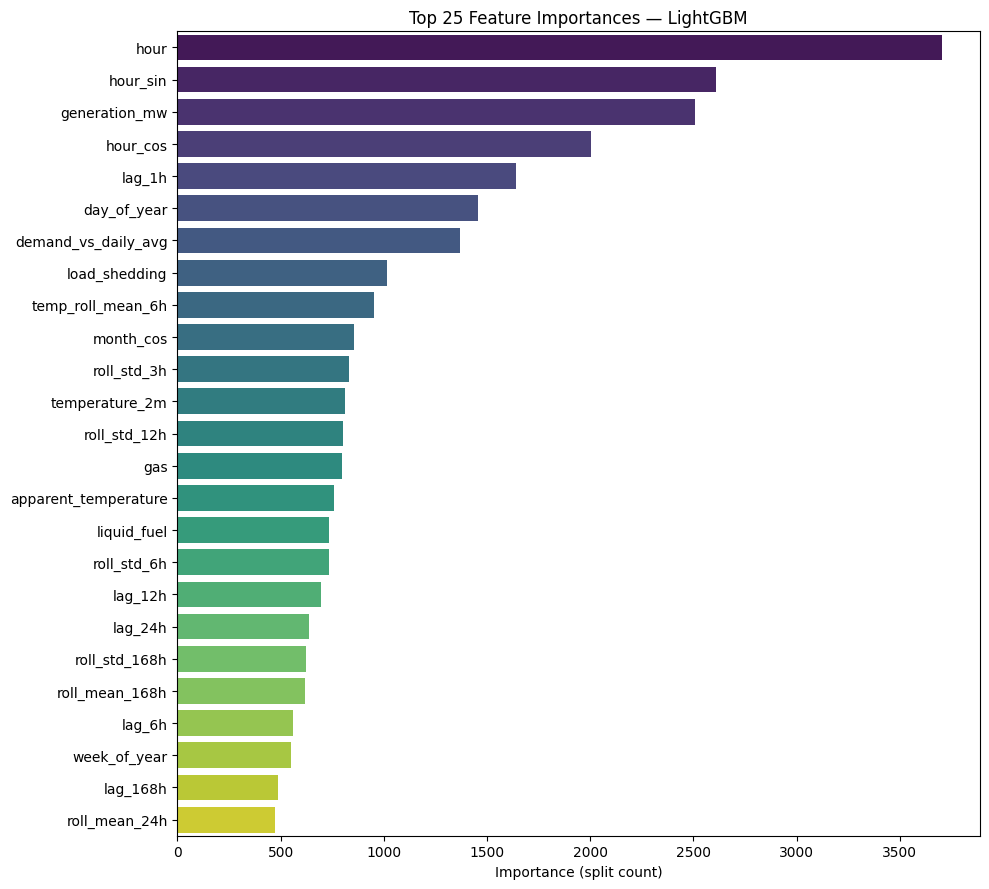

Top 15 features:
             feature  importance
                hour        3703
            hour_sin        2609
       generation_mw        2505
            hour_cos        2003
              lag_1h        1642
         day_of_year        1455
 demand_vs_daily_avg        1370
       load_shedding        1015
   temp_roll_mean_6h         954
           month_cos         854
         roll_std_3h         829
      temperature_2m         814
        roll_std_12h         802
                 gas         797
apparent_temperature         759


In [8]:
importance_df = pd.DataFrame({
    'feature'   : FEATURE_COLS,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

TOP_N = 25
fig, ax = plt.subplots(figsize=(10, 9))
sns.barplot(
    data=importance_df.head(TOP_N),
    x='importance', y='feature',
    palette='viridis', ax=ax
)
ax.set_title(f'Top {TOP_N} Feature Importances — LightGBM')
ax.set_xlabel('Importance (split count)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print('Top 15 features:')
print(importance_df.head(15).to_string(index=False))